<a href="https://colab.research.google.com/github/Atay455/My_ML_Jorney_Projects/blob/main/House_Price_Prediction/House_Price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics



In [3]:
data = pd.read_csv('/content/AMES_Final_DF.csv')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Columns: 274 entries, Lot Frontage to Sale Condition_Partial
dtypes: float64(11), int64(263)
memory usage: 6.1 MB


In [4]:
data.head(10)

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,...,0,0,0,0,1,0,0,0,1,0
1,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,...,0,0,0,0,1,0,0,0,1,0
2,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,...,0,0,0,0,1,0,0,0,1,0
3,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,...,0,0,0,0,1,0,0,0,1,0
4,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,...,0,0,0,0,1,0,0,0,1,0
5,78.0,9978,6,6,1998,1998,20.0,602.0,0.0,324.0,...,0,0,0,0,1,0,0,0,1,0
6,41.0,4920,8,5,2001,2001,0.0,616.0,0.0,722.0,...,0,0,0,0,1,0,0,0,1,0
7,43.0,5005,8,5,1992,1992,0.0,263.0,0.0,1017.0,...,0,0,0,0,1,0,0,0,1,0
8,39.0,5389,8,5,1995,1996,0.0,1180.0,0.0,415.0,...,0,0,0,0,1,0,0,0,1,0
9,60.0,7500,7,5,1999,1999,0.0,0.0,0.0,994.0,...,0,0,0,0,1,0,0,0,1,0


In [7]:
print(data)

      Lot Frontage  Lot Area  Overall Qual  Overall Cond  Year Built  \
0       141.000000     31770             6             5        1960   
1        80.000000     11622             5             6        1961   
2        81.000000     14267             6             6        1958   
3        93.000000     11160             7             5        1968   
4        74.000000     13830             5             5        1997   
...            ...       ...           ...           ...         ...   
2920     37.000000      7937             6             6        1984   
2921     75.144444      8885             5             5        1983   
2922     62.000000     10441             5             5        1992   
2923     77.000000     10010             5             5        1974   
2924     74.000000      9627             7             5        1993   

      Year Remod/Add  Mas Vnr Area  BsmtFin SF 1  BsmtFin SF 2  Bsmt Unf SF  \
0               1960         112.0         639.0        

In [16]:
data["SalePrice"]

,SalePrice
0,215000
1,105000
2,172000
3,244000
4,189900
...,...
2920,142500
2921,131000
2922,132000
2923,170000


In [18]:
data.shape

(2925, 274)

In [19]:
# Checking for missing values
data.isnull().sum()

,0
Lot Frontage,0
Lot Area,0
Overall Qual,0
Overall Cond,0
Year Built,0
...,...
Sale Condition_AdjLand,0
Sale Condition_Alloca,0
Sale Condition_Family,0
Sale Condition_Normal,0


In [20]:
# Statistical Measure
data.describe()

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
count,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,...,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000,2925.000000
mean,69.683099,10109.861538,6.091624,5.563761,1971.323761,1984.229060,100.318632,438.974359,49.790427,558.959316,...,0.002735,0.080684,0.002393,0.000342,0.866325,0.004103,0.007863,0.015726,0.824615,0.082735
std,21.344161,7785.509739,1.406386,1.112262,30.228826,20.857822,176.667803,439.426274,169.274143,439.729905,...,0.052235,0.272395,0.048870,0.018490,0.340361,0.063931,0.088341,0.124437,0.380361,0.275528
min,0.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,7438.000000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,218.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,70.000000,9430.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,465.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,80.000000,11526.000000,7.000000,6.000000,2000.000000,2004.000000,162.000000,734.000000,0.000000,801.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,2288.000000,1526.000000,2336.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Undestanding the corrrelation between various features in dataset**

1.Positive Correlation

2.Negatuive Correlation

In [21]:
correlation = data.corr()

In [22]:
correlation

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
Lot Frontage,1.000000,0.377876,0.189348,-0.056755,0.118491,0.080929,0.198320,0.165424,0.058360,0.103582,...,-0.041860,0.089015,-0.003026,0.013273,-0.066157,-0.047920,0.010944,0.017036,-0.067966,0.086950
Lot Area,0.377876,1.000000,0.085037,-0.032696,0.017569,0.016329,0.106717,0.157676,0.085724,0.022183,...,-0.015529,0.016193,-0.003749,0.008696,-0.002633,-0.020194,0.026272,0.019088,-0.013794,0.018291
Overall Qual,0.189348,0.085037,1.000000,-0.093812,0.596804,0.569720,0.416306,0.273297,-0.040615,0.269886,...,-0.045311,0.329752,-0.052951,-0.014357,-0.185885,-0.049827,-0.038833,-0.023870,-0.127224,0.324635
Overall Cond,-0.056755,-0.032696,-0.093812,1.000000,-0.368327,0.048431,-0.131679,-0.049316,0.040839,-0.137086,...,-0.014776,-0.146797,-0.018538,0.007254,0.161192,-0.051776,-0.027728,-0.031957,0.167505,-0.142207
Year Built,0.118491,0.017569,0.596804,-0.368327,1.000000,0.612085,0.305046,0.281601,-0.027051,0.128694,...,-0.044962,0.341557,-0.013952,-0.008153,-0.201016,-0.077845,-0.019524,-0.036176,-0.136495,0.337101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sale Condition_AdjLand,-0.047920,-0.020194,-0.049827,-0.051776,-0.077845,-0.078160,-0.018132,-0.028714,-0.018882,-0.006369,...,-0.003361,-0.019014,-0.003144,-0.001187,0.025212,1.000000,-0.005714,-0.008113,-0.139172,-0.019276
Sale Condition_Alloca,0.010944,0.026272,-0.038833,-0.027728,-0.019524,-0.037357,-0.017603,0.027166,-0.026191,-0.060114,...,-0.004662,-0.026374,-0.004360,-0.001646,0.034970,-0.005714,1.000000,-0.011253,-0.193039,-0.026737
Sale Condition_Family,0.017036,0.019088,-0.023870,-0.031957,-0.036176,-0.049615,-0.016811,-0.026461,-0.002149,0.024518,...,0.045996,-0.037447,0.050048,-0.002338,-0.014946,-0.008113,-0.011253,1.000000,-0.274087,-0.037963
Sale Condition_Normal,-0.067966,-0.013794,-0.127224,0.167505,-0.136495,-0.100290,-0.056903,0.001843,0.068636,-0.149745,...,0.006938,-0.642378,-0.087804,0.008529,0.619284,-0.139172,-0.193039,-0.274087,1.000000,-0.651219


In [29]:
# constructing a heatmap to understand a correlation
correlations = data.corr()['SalePrice'].sort_values(ascending=False)

In [30]:
top_features = correlations.head(11).index.tolist() + correlations.tail(10).index.tolist()

<Axes: >

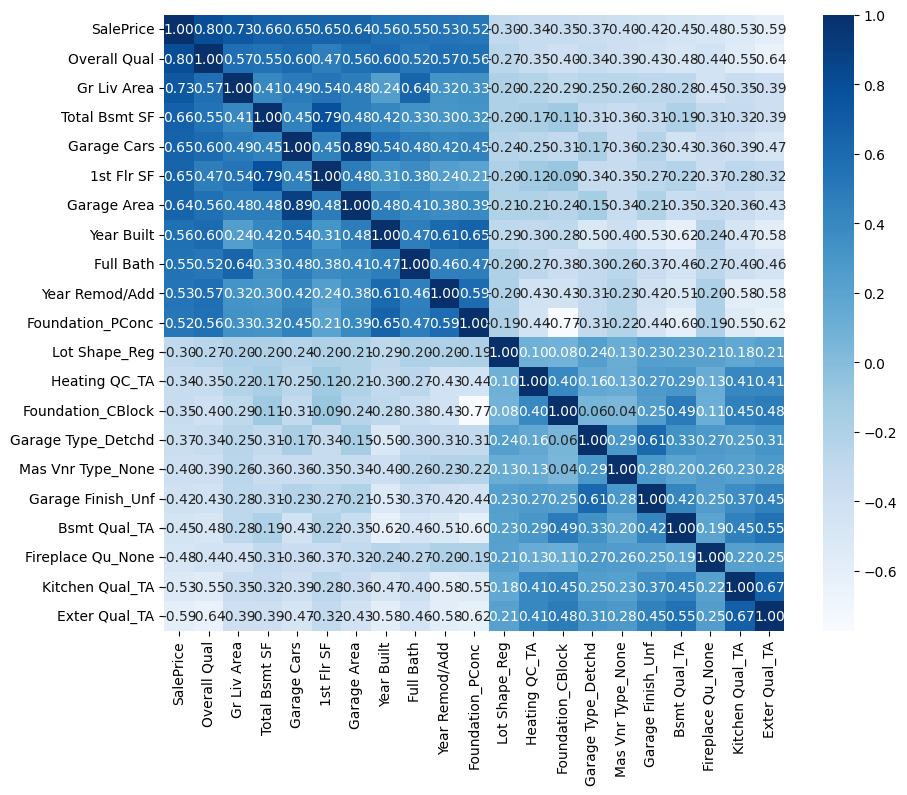

In [31]:
plt.figure(figsize=(10, 8))
sns.heatmap(data[top_features].corr(), annot=True, cmap='Blues', fmt=".2f")

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


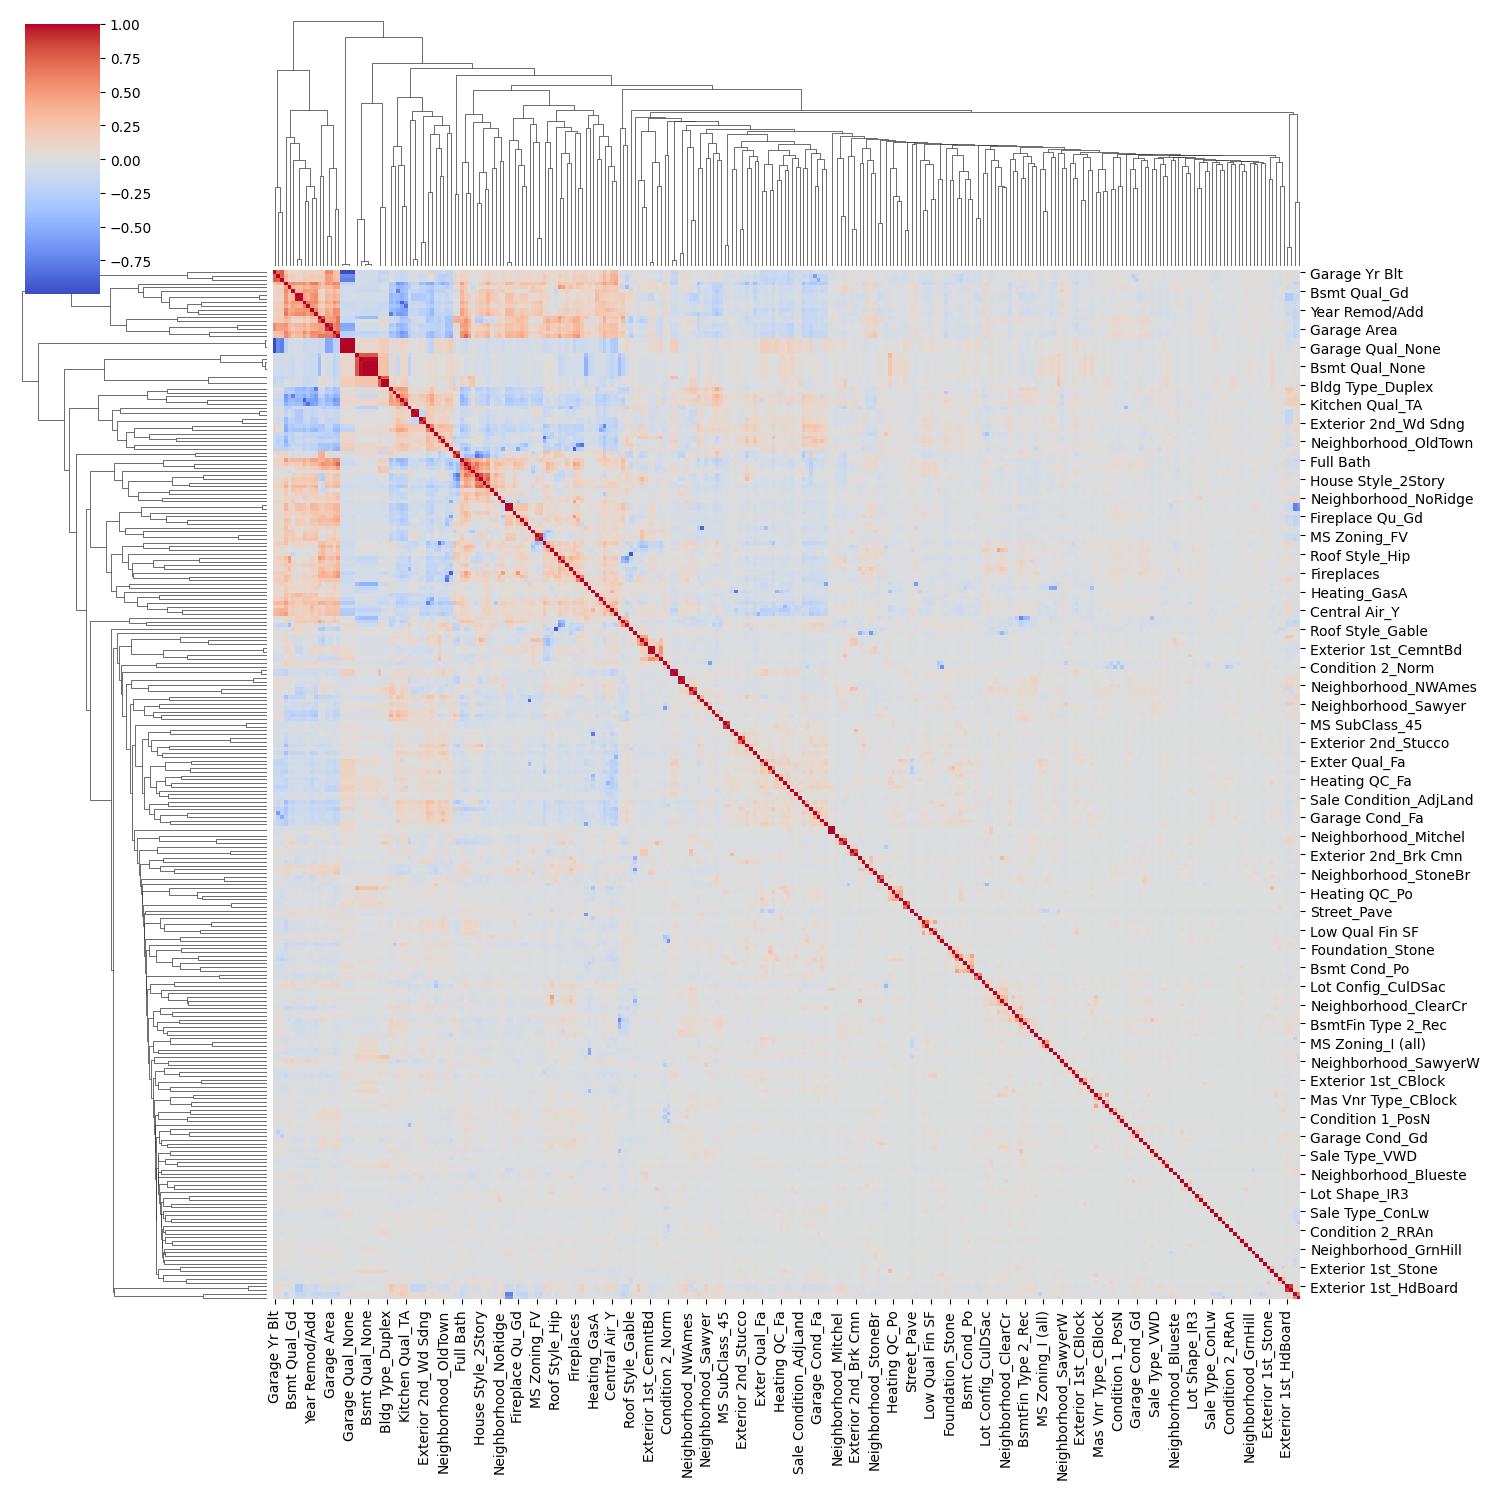

In [32]:
sns.clustermap(data.corr(), cmap='coolwarm', figsize=(15, 15))

In [34]:
X = data.drop(["SalePrice"],axis = 1)

Y = data['SalePrice']

In [35]:
print(X)
print(Y)

      Lot Frontage  Lot Area  Overall Qual  Overall Cond  Year Built  \
0       141.000000     31770             6             5        1960   
1        80.000000     11622             5             6        1961   
2        81.000000     14267             6             6        1958   
3        93.000000     11160             7             5        1968   
4        74.000000     13830             5             5        1997   
...            ...       ...           ...           ...         ...   
2920     37.000000      7937             6             6        1984   
2921     75.144444      8885             5             5        1983   
2922     62.000000     10441             5             5        1992   
2923     77.000000     10010             5             5        1974   
2924     74.000000      9627             7             5        1993   

      Year Remod/Add  Mas Vnr Area  BsmtFin SF 1  BsmtFin SF 2  Bsmt Unf SF  \
0               1960         112.0         639.0        

In [36]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2,random_state=42)

In [37]:
print(X.shape,X_train.shape,X_test.shape)

(2925, 273) (2340, 273) (585, 273)


**Model Training**

XGBoost Regressor

In [41]:
model = XGBRegressor()

In [42]:
model.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [44]:
# prediction on traing data , cheking accuracy
training_data_prediction = model.predict(X_train)

In [45]:
print(training_data_prediction)

[167202.98  223989.7   125762.195 ... 205110.66  121632.54  133626.19 ]


In [47]:
# R squared error
score_1 = metrics.r2_score(Y_train, training_data_prediction)

# Mean Absolute Error

score_2 = metrics.mean_absolute_error(Y_train, training_data_prediction)


print ("R squared error:", score_1)
print ("Mean Absolute Error:", score_2)

R squared error: 0.9984745383262634
Mean Absolute Error: 2208.987060546875


In [49]:
# Prediction on test data
test_data_prediction = model.predict(X_test)


In [50]:
# R squared error
score_1 = metrics.r2_score(Y_test, test_data_prediction)

# Mean Absolute Error

score_2 = metrics.mean_absolute_error(Y_test, test_data_prediction)


print ("R squared error:", score_1)
print ("Mean Absolute Error:", score_2)

R squared error: 0.9341544508934021
Mean Absolute Error: 14355.1025390625


* Checking the Mean Absolute Error 14355 price according actual mean and prediction which means MAE is off 8% from actual roices, which not bad

In [61]:
print(data['SalePrice'].describe())

count      2925.000000
mean     180815.537436
std       79951.696564
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [62]:
mean_of_prices

np.float64(180815.53743589742)

<Axes: xlabel='SalePrice', ylabel='Count'>

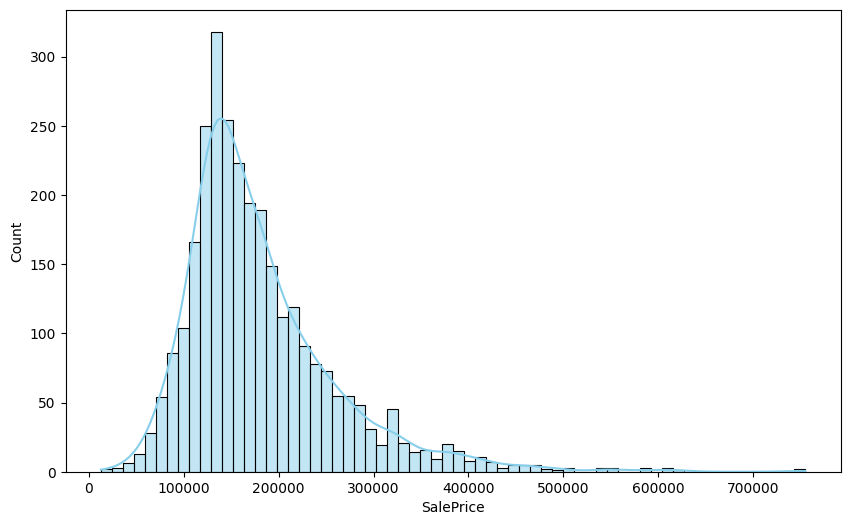

In [60]:
plt.figure(figsize=(10, 6))
sns.histplot(data['SalePrice'], kde=True, color='skyblue')

* Visualizing the actual price and predicted price

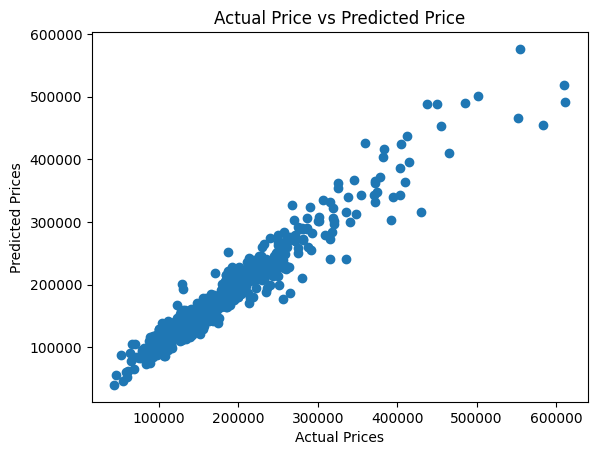

In [65]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Price vs Predicted Price")
plt.show()